# Student Performance Analysis

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading the student performance dataset

In [2]:
df = pd.read_csv("data/xAPI-Edu-Data.csv")
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


## 2. Initial Data Inspection

checking the shape, column types, and missing values.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (480, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  Parentsch

In [4]:
df.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

## 3. Feature Engineering

The raw dataset has four separate behavioral/engagement columns:
`raisedhands`, `VisITedResources`, `AnnouncementsView`, `Discussion`.

I Created an `EngagementScore` by averaging four engagement-related metrics to simplify analysis and reporting.

I also converted `StudentAbsenceDays` (which is `'Under-7'` / `'Above-7'`) into a binary
**AttendanceRisk** flag, and mapped the `Class` performance label (`L`/`M`/`H`) to a numeric
**PerformanceProxy** score so it can be averaged and charted.

In [5]:
# Standardize column names
df.columns = [c.strip() for c in df.columns]

In [6]:
# 3a. Engagement Score
engagement_cols = ["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion"]
df["EngagementScore"] = df[engagement_cols].mean(axis=1).round(1)

In [7]:
# 3b. Attendance Risk flag
df["AttendanceRisk"] = df["StudentAbsenceDays"].apply(lambda x: 1 if x == "Above-7" else 0)

In [8]:
# 3c. Numeric performance proxy (L=Low 0-69, M=Mid 70-89, H=High 90-100 -> midpoint)
class_to_score = {"L": 50, "M": 80, "H": 95}
df["PerformanceProxy"] = df["Class"].map(class_to_score)

In [9]:
df[["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion","EngagementScore",
    "StudentAbsenceDays", "AttendanceRisk", "Class", "PerformanceProxy"]].head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,EngagementScore,StudentAbsenceDays,AttendanceRisk,Class,PerformanceProxy
0,15,16,2,20,13.2,Under-7,0,M,80
1,20,20,3,25,17.0,Under-7,0,M,80
2,10,7,0,30,11.8,Above-7,1,L,50
3,30,25,5,35,23.8,Above-7,1,L,50
4,40,50,12,50,38.0,Above-7,1,M,80


## 4. Performance & Engagement Trends by Subject

Grouping by `Topic` (subject) shows which subjects have the strongest/weakest average
performance and engagement, it's useful for spotting subjects that might need extra support.

Also Visualizing the average performance score for each subject using a bar chart.

In [10]:
subject_trends = (
    df.groupby("Topic")[["EngagementScore", "PerformanceProxy"]]
    .mean()
    .round(1)
    .sort_values("PerformanceProxy", ascending=False)
)
subject_trends

,EngagementScore,PerformanceProxy
Topic,,
Biology,60.6,84.0
Geology,67.4,83.8
English,45.6,79.0
Science,54.3,78.8
History,62.7,78.4
Quran,51.9,77.3
French,40.6,77.2
Arabic,45.1,76.2
Chemistry,51.9,76.2


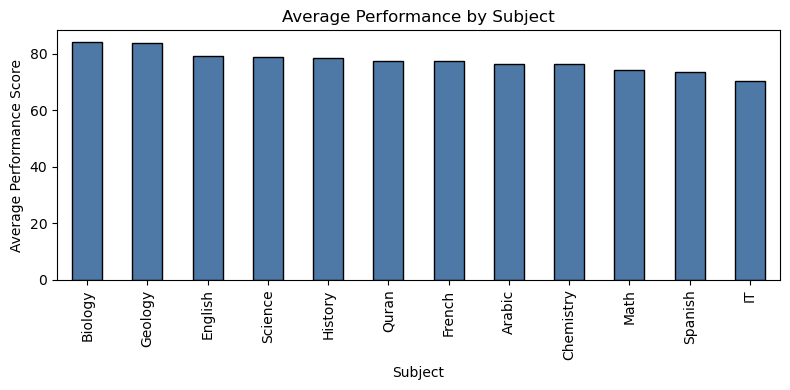

In [11]:
subject_trends["PerformanceProxy"].plot(kind="bar", figsize=(8,4), edgecolor="black", color="#4E79A7", title="Average Performance by Subject")
plt.ylabel("Average Performance Score")
plt.xlabel("Subject")
plt.tight_layout()
plt.show()

## 5. Semester-wise and Grade-level Trends

Comparing the First vs Second semester, and across grade levels, helps spot whether
engagement or performance is dropping over time or in specific grades.

In [12]:
semester_trends = (
    df.groupby("Semester")[["EngagementScore", "PerformanceProxy"]]
    .mean()
    .round(1)
)
semester_trends

,EngagementScore,PerformanceProxy
Semester,,
F,41.0,74.4
S,50.6,78.7


In [13]:
grade_trends = (
    df.groupby("GradeID")[["EngagementScore", "PerformanceProxy"]]
    .mean()
    .round(1)
    .sort_index()
)
grade_trends

,EngagementScore,PerformanceProxy
GradeID,,
G-02,37.6,74.0
G-04,48.2,77.5
G-05,17.2,50.0
G-06,52.2,84.7
G-07,47.0,76.0
G-08,52.7,77.8
G-09,38.2,74.0
G-10,36.5,76.2
G-11,57.2,82.3


## 6. At-Risk Student Flagging (Rule-Based)

A student is flagged **"At Risk"** if all three conditions are true:
1. Absence days are `Above-7`
2. Their `EngagementScore` is below the dataset median
3. Their performance `Class` is Low or Medium (not already a high performer)

This mirrors a simple, explainable threshold-based approach - the kind of logic a school
platform could realistically use to auto-flag students for teacher follow-up.

In [14]:
median_engagement = df["EngagementScore"].median()

def flag_at_risk(row):
    if (
        row["AttendanceRisk"] == 1
        and row["EngagementScore"] < median_engagement
        and row["Class"] in ["L", "M"]
    ):
        return "At Risk"
    return "On Track"

df["RiskStatus"] = df.apply(flag_at_risk, axis=1)

df["RiskStatus"].value_counts()

RiskStatus
On Track    332
At Risk     148
Name: count, dtype: int64

In [15]:
# Calculate the total number and percentage of at-risk students
at_risk_count = (df["RiskStatus"] == "At Risk").sum()
at_risk_pct = (at_risk_count / len(df)) * 100

print(f"{at_risk_count} of {len(df)} students flagged At Risk ({at_risk_pct:.1f}%)")

148 of 480 students flagged At Risk (30.8%)


#### Quick visual: Engagement vs Performance, colored by risk status

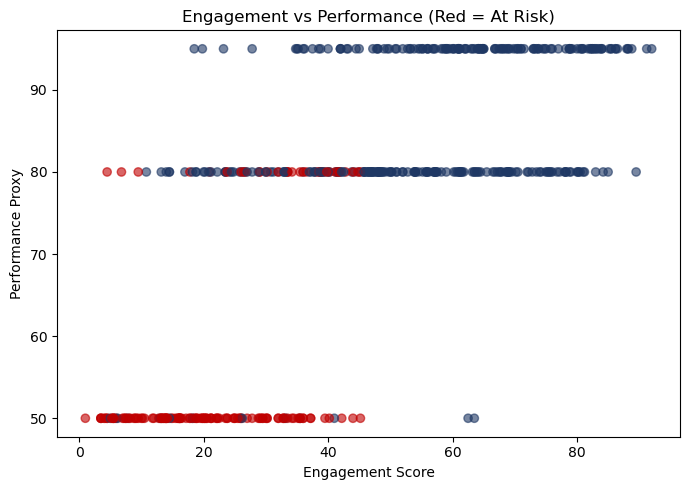

In [16]:
colors = df["RiskStatus"].map({"At Risk": "#C00000", "On Track": "#1F3864"})
plt.figure(figsize=(7,5))
plt.scatter(df["EngagementScore"], df["PerformanceProxy"], c=colors, alpha=0.6)
plt.xlabel("Engagement Score")
plt.ylabel("Performance Proxy")
plt.title("Engagement vs Performance (Red = At Risk)")
plt.tight_layout()
plt.show()

## 7. Export Cleaned Data for Power BI

Export the final processed dataset.

In [17]:
export_cols = [
    "gender", "Topic", "Semester", "GradeID", "SectionID",
    "raisedhands", "VisITedResources", "AnnouncementsView", "Discussion",
    "EngagementScore", "StudentAbsenceDays", "AttendanceRisk",
    "Class", "PerformanceProxy", "RiskStatus"
]
df[export_cols].to_csv("data/edu_analytics_processed.csv", index=False)
print("Exported -> data/edu_analytics_processed.csv")

Exported -> data/edu_analytics_processed.csv
